In [1]:
%load_ext autotime

time: 75.6 μs (started: 2026-03-15 19:05:52 +08:00)


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix



import warnings
warnings.filterwarnings('ignore')

time: 1.57 s (started: 2026-03-15 19:05:52 +08:00)


In [ ]:
path = "/Users/wpmangapot/Desktop/WorkFolder/Projects/stat280_pml/data/fraudTrain.csv"
df = pd.read_csv(path)
df.head(5)

# You can also look on the dataset in kaggle: https://www.kaggle.com/datasets/kartik2112/fraud-detection

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


time: 4.85 s (started: 2026-03-15 19:05:54 +08:00)


In [4]:
df.shape

(1296675, 23)

time: 1.04 ms (started: 2026-03-15 19:05:59 +08:00)


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

time: 453 ms (started: 2026-03-15 19:05:59 +08:00)


It seems that there is no misisng values in our dataset. 

In [7]:
# check for duplicated records
df.duplicated().sum()

0

time: 1.96 s (started: 2026-03-15 19:06:00 +08:00)


There is no duplicated records in our dataset

In [8]:
# drop irrelevent col 
df.drop(columns=['Unnamed: 0', 'cc_num', 'first', 'first', 'last', 'unix_time', 'trans_num', 'street', 'city'], inplace=True)

time: 53.4 ms (started: 2026-03-15 19:06:02 +08:00)


In fraud detection, columns like Unnamed: 0, cc_num, first, last, unix_time, trans_num, street, and city are typically dropped because they either serve as unique identifiers, contain personally identifiable information (PII), or provide raw data that does not directly contribute to detecting fraudulent patterns. Unique IDs such as credit card numbers or transaction numbers offer no predictive value and can cause the model to memorize specific instances rather than learn generalizable fraud behaviors. Similarly, personal details like names or addresses have high cardinality and risk overfitting, while raw timestamps are better transformed into meaningful features like transaction hour or day of the week. Removing these columns simplifies the dataset, reduces noise, and focuses the model on features that truly reflect fraud patterns.

In [9]:
# convert to correct datetime type
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

time: 260 ms (started: 2026-03-15 19:06:02 +08:00)


In [10]:
# extract features from data - feature engg
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year
df['hour'] = df['trans_date_trans_time'].dt.hour
df['minute'] = df['trans_date_trans_time'].dt.minute

df.drop(columns=['trans_date_trans_time'], inplace=True)

time: 228 ms (started: 2026-03-15 19:06:02 +08:00)


We use this type of feature extraction in fraud detection to transform raw timestamp data into meaningful components that can reveal patterns of fraudulent behavior. By breaking down trans_date_trans_time into day, month, year, hour, and minute, we capture temporal patterns such as unusual transaction times, high-frequency transactions during specific hours, or seasonal spikes in fraud activity. These derived features are more informative for the model than the raw datetime column because they allow it to learn patterns related to the timing of transactions. After extracting these features, the original trans_date_trans_time column can be dropped since it no longer provides additional predictive value, streamlining the dataset and improving the efficiency and interpretability of the model.

In [11]:
# extract age of person
df['dob'] = pd.to_datetime(df['dob'])
df['year_dob'] = df['dob'].dt.year
df['age'] = df['year'] - df['year_dob']

time: 342 ms (started: 2026-03-15 19:06:02 +08:00)


This code converts the date of birth (dob) into a datetime format and extracts the birth year, then calculates the person’s age at the time of the transaction by subtracting the birth year from the transaction year. Age is meaningful because it summarizes demographic information in a single numerical feature that can influence spending or transaction behavior, allowing the model to detect patterns without relying on the raw, high-cardinality dob column.

In [12]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].mean())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
0.005788651743883394
time: 15.3 ms (started: 2026-03-15 19:06:03 +08:00)


This tells us a few important things about your dataset:

1. Class imbalance: Only 0.58% of transactions are fraudulent (is_fraud = 1), while over 99% are legitimate. This is an extremely imbalanced dataset, which is very common in fraud detection.

2. Implications for modeling:
-Standard models might default to predicting non-fraud because it achieves over 99% accuracy.
- We may need techniques like:
    - Resampling: oversample fraud (SMOTE) or undersample non-fraud
    - Class weights: penalize misclassifying fraud in models like Random Forest or XGBoost
    - Anomaly detection models: focus on rare events

3. Evaluation metrics:
- Accuracy is misleading here. Better metrics are:
- Precision, recall, F1-score
- ROC-AUC or PR-AUC

# Exploratory Data Analysis

In [13]:
df.dtypes

merchant              object
category              object
amt                  float64
gender                object
state                 object
zip                    int64
lat                  float64
long                 float64
city_pop               int64
job                   object
dob           datetime64[ns]
merch_lat            float64
merch_long           float64
is_fraud               int64
day                    int32
month                  int32
year                   int32
hour                   int32
minute                 int32
year_dob               int32
age                    int32
dtype: object

time: 60.3 ms (started: 2026-03-15 19:06:03 +08:00)


In [14]:
# Numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Categorical features
categorical_features = df.select_dtypes(include=['object', 'category', 'datetime64[ns]']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud', 'day', 'month', 'year', 'hour', 'minute', 'year_dob', 'age']
Categorical features: ['merchant', 'category', 'gender', 'state', 'job', 'dob']
time: 76.5 ms (started: 2026-03-15 19:06:03 +08:00)


In [15]:
# inspect numeric features
df[numeric_features].describe()

,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,day,month,year,hour,minute,year_dob,age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,3.853734e+01,-9.022646e+01,5.788652e-03,1.558798e+01,6.142150e+00,2.019287e+03,1.280486e+01,2.949529e+01,1.973257e+03,4.602930e+01
std,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,5.109788e+00,1.377109e+01,7.586269e-02,8.829121e+00,3.417703e+00,4.522452e-01,6.817824e+00,1.732018e+01,1.737848e+01,1.738237e+01
min,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.902779e+01,-1.666712e+02,0.000000e+00,1.000000e+00,1.000000e+00,2.019000e+03,0.000000e+00,0.000000e+00,1.924000e+03,1.400000e+01
25%,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,3.473357e+01,-9.689728e+01,0.000000e+00,8.000000e+00,3.000000e+00,2.019000e+03,7.000000e+00,1.400000e+01,1.962000e+03,3.300000e+01
50%,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,3.936568e+01,-8.743839e+01,0.000000e+00,1.500000e+01,6.000000e+00,2.019000e+03,1.400000e+01,3.000000e+01,1.975000e+03,4.400000e+01
75%,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,4.195716e+01,-8.023680e+01,0.000000e+00,2.300000e+01,9.000000e+00,2.020000e+03,1.900000e+01,4.400000e+01,1.987000e+03,5.700000e+01
max,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,3.100000e+01,1.200000e+01,2.020000e+03,2.300000e+01,5.900000e+01,2.005000e+03,9.600000e+01


time: 650 ms (started: 2026-03-15 19:06:03 +08:00)


In [16]:
# inspect categorical features
df[categorical_features].describe(include='object')

,merchant,category,gender,state,job
count,1296675,1296675,1296675,1296675,1296675
unique,693,14,2,51,494
top,fraud_Kilback LLC,gas_transport,F,TX,Film/video editor
freq,4403,131659,709863,94876,9779


time: 585 ms (started: 2026-03-15 19:06:04 +08:00)


### Fraud rate per category

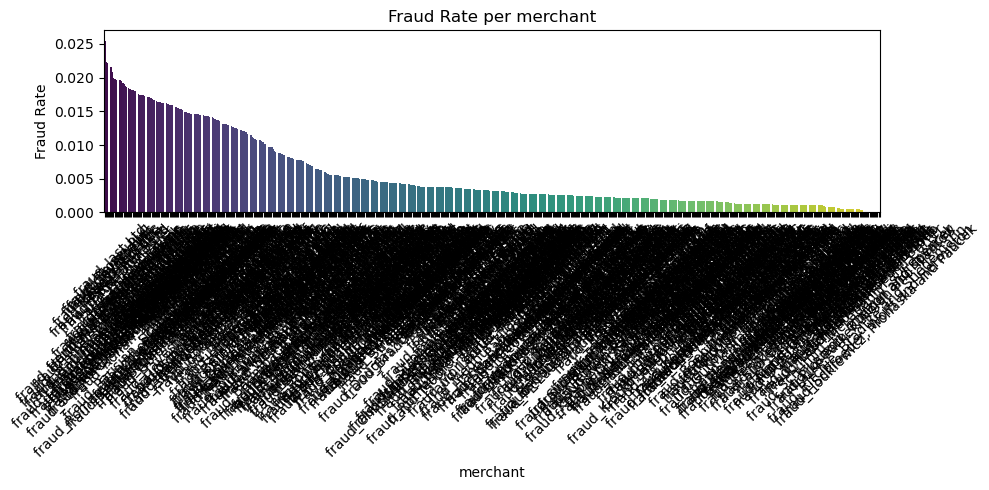

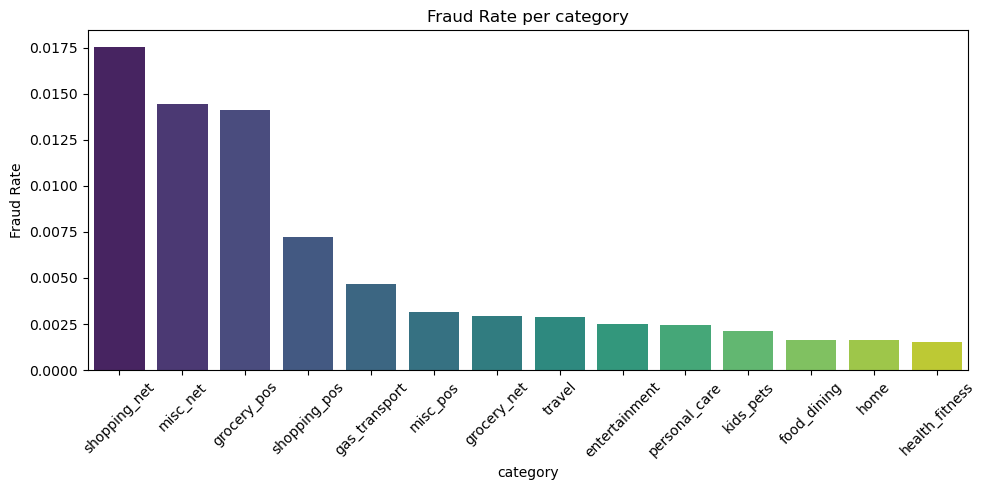

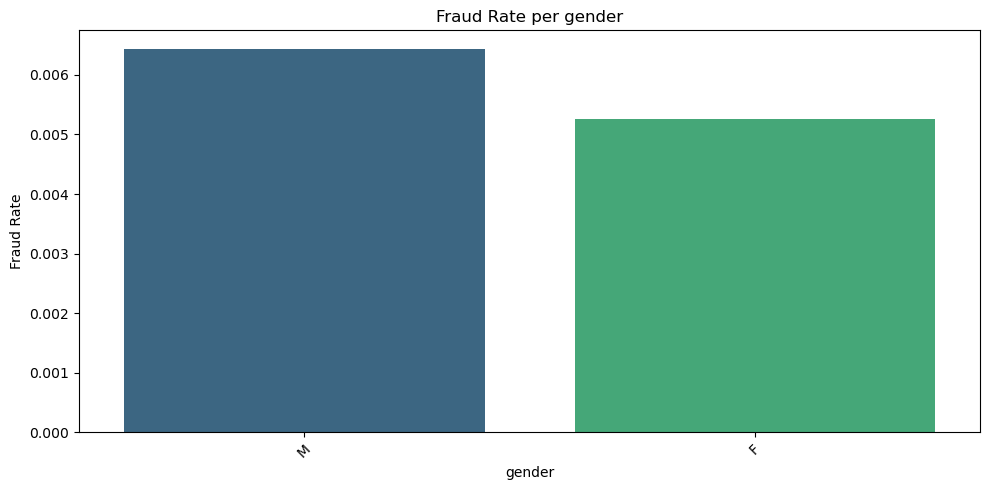

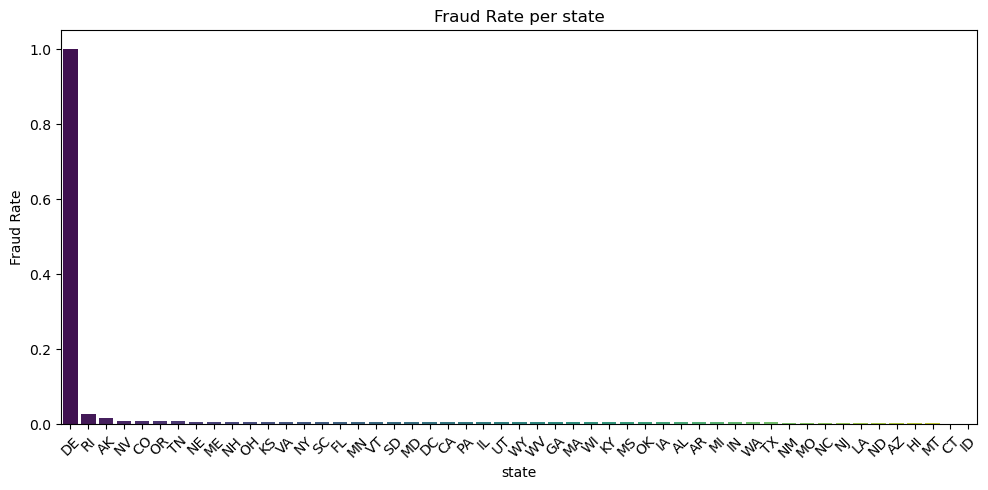

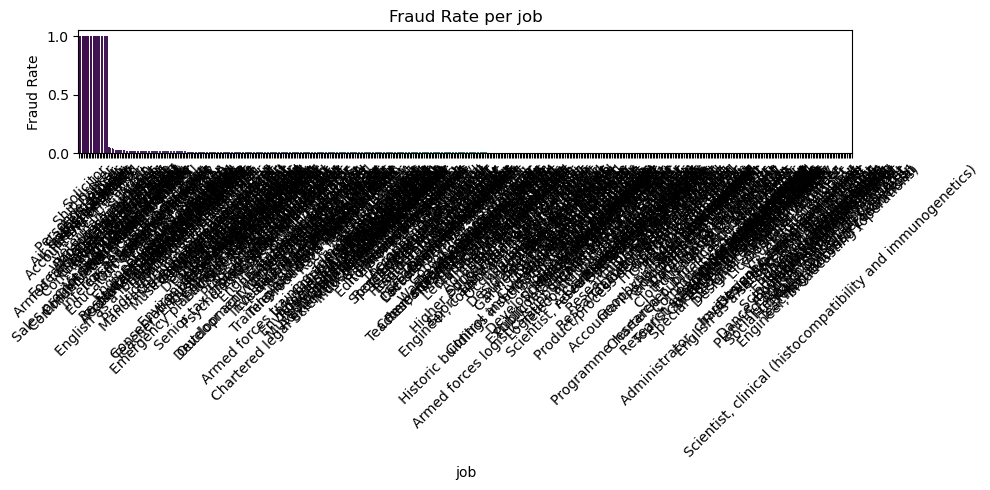

time: 9.55 s (started: 2026-03-15 19:06:04 +08:00)


In [17]:
for col in categorical_features:
    # Skip datetime columns if you don't want to plot raw dates
    if df[col].dtype == 'datetime64[ns]':
        continue
    
    # Compute fraud rate per category
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    
    # Plot
    plt.figure(figsize=(10,5))
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='viridis')
    plt.xticks(rotation=45)
    plt.ylabel('Fraud Rate')
    plt.xlabel(col)
    plt.title(f'Fraud Rate per {col}')
    plt.tight_layout()
    plt.show()


In [18]:
# Loop through categorical features
for col in categorical_features:
    # Skip datetime columns
    if df[col].dtype == 'datetime64[ns]':
        continue
    
    # Compute fraud rate per category
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    
    print(f"\nFeature: {col}")
    
    if len(fraud_rate) > 3:
        # Top 3
        top3 = fraud_rate.head(3)
        print("Top 3 fraud categories:")
        print(top3)
        
        # Bottom 3
        bottom3 = fraud_rate.tail(3)
        print("\nBottom 3 fraud categories:")
        print(bottom3)
    else:
        # If 3 or fewer categories, just print all
        print(fraud_rate)



Feature: merchant
Top 3 fraud categories:
merchant
fraud_Kozey-Boehm                    0.025723
fraud_Herman, Treutel and Dickens    0.025385
fraud_Kerluke-Abshire                0.022307
Name: is_fraud, dtype: float64

Bottom 3 fraud categories:
merchant
fraud_Schroeder, Wolff and Hermiston    0.0
fraud_Gulgowski LLC                     0.0
fraud_Schroeder Group                   0.0
Name: is_fraud, dtype: float64

Feature: category
Top 3 fraud categories:
category
shopping_net    0.017561
misc_net        0.014458
grocery_pos     0.014098
Name: is_fraud, dtype: float64

Bottom 3 fraud categories:
category
food_dining       0.001651
home              0.001608
health_fitness    0.001549
Name: is_fraud, dtype: float64

Feature: gender
gender
M    0.006426
F    0.005262
Name: is_fraud, dtype: float64

Feature: state
Top 3 fraud categories:
state
DE    1.000000
RI    0.027273
AK    0.016981
Name: is_fraud, dtype: float64

Bottom 3 fraud categories:
state
MT    0.002722
CT    0.002077
ID 

1. Merchant: Top 3 fraud-prone merchants: fraud_Kozey-Boehm (2.57%), fraud_Herman, Treutel and Dickens (2.54%), fraud_Kerluke-Abshire (2.23%). These merchants have the highest proportion of fraudulent transactions, suggesting that certain merchants are more likely to be associated with fraud. Bottom 3 merchants: All show 0% fraud, indicating these merchants have not had any recorded fraudulent transactions in the dataset.

2. Category: Top 3 fraud categories: shopping_net (1.76%), misc_net (1.45%), grocery_pos (1.41%). Online shopping (shopping_net) and certain miscellaneous/net transactions have higher fraud rates, implying online or POS transactions are more vulnerable. Bottom 3 categories: food_dining, home, health_fitness (<0.17%), indicating these transaction types are low-risk.

3. Gender: Males (M) have a slightly higher fraud rate (0.64%) than females (F, 0.53%). The difference is small, suggesting gender is not a strong predictor, but males have a marginally higher tendency to be involved in fraudulent transactions in this dataset.

4. State: Top 3 states by fraud rate: DE (100%), RI (2.73%), AK (1.70%). DE shows 100% fraud, but this likely reflects very few transactions from that state, making it a small-sample effect. Bottom 3 states: MT, CT, ID (~0.2%), indicating low fraud risk in these regions.

5. Job: Top 3 fraud jobs: Personnel officer, Air traffic controller, Accountant, chartered all show 100% fraud. Again, these extreme values likely result from very few instances in the dataset, so caution is needed in interpretation. Bottom 3 jobs: Animal technologist, Horticulturist, commercial, Insurance broker all show 0% fraud, suggesting no fraud recorded for these occupations.

### Fraud rate by time

In [19]:
def fraud_rate_by_time(feature):
    # Group by time feature and fraud status
    temp = df.groupby([feature, 'is_fraud'])['is_fraud'].count().unstack(fill_value=0)

    # Rename columns for clarity
    temp.columns = ['non_fraud', 'fraud']

    # Add total transactions and fraud rate
    temp['total_txn'] = temp['non_fraud'] + temp['fraud']
    temp['fraud_rate_%'] = (temp['fraud'] / temp['total_txn']) * 100

    return temp.sort_values(by=feature)

time: 559 μs (started: 2026-03-15 19:06:14 +08:00)


In [20]:
# Apply to all time-based features
fraud_by_year = fraud_rate_by_time('year')
fraud_by_year

,non_fraud,fraud,total_txn,fraud_rate_%
year,,,,
2019,919630,5220,924850,0.564416
2020,369539,2286,371825,0.614805


time: 102 ms (started: 2026-03-15 19:06:14 +08:00)


Even though the total number of transactions dropped significantly in 2020, the fraud rate increased slightly, from 0.56% to 0.61%.

This suggests that fraudulent transactions became slightly more frequent relative to the total transactions, which could indicate changing fraud patterns or more targeted fraud attempts in 2020.

This type of temporal analysis is useful for monitoring trends and identifying years with higher relative fraud risk, helping in planning fraud prevention strategies.

In [21]:
fraud_by_month = fraud_rate_by_time('month')
fraud_by_month

,non_fraud,fraud,total_txn,fraud_rate_%
month,,,,
1,103878,849,104727,0.810679
2,96804,853,97657,0.873465
3,142851,938,143789,0.652345
4,134292,678,134970,0.502334
5,145940,935,146875,0.636596
6,143123,688,143811,0.478406
7,86265,331,86596,0.382235
8,86977,382,87359,0.437276
9,70234,418,70652,0.591632


time: 52.7 ms (started: 2026-03-15 19:06:14 +08:00)


Early-year months (Jan–Feb) appear to have higher relative fraud risk, which could indicate seasonal patterns or targeted fraud attempts during those months.

In [ ]:
fraud_by_day = fraud_rate_by_time('day')
fraud_by_day

time: 237 ms (started: 2026-03-15 19:06:14 +08:00)


Early and mid-month days show moderate fraud rates (0.4–0.65%), while certain end-of-month days (20th, 31st) experience higher relative fraud incidence, suggesting that fraudsters may target specific days, possibly aligned with pay cycles, billing, or reporting periods.

In [23]:
fraud_by_hour = fraud_rate_by_time('hour')
fraud_by_hour

,non_fraud,fraud,total_txn,fraud_rate_%
hour,,,,
0,41867,635,42502,1.494047
1,42211,658,42869,1.534909
2,42031,625,42656,1.465210
3,42160,609,42769,1.423929
4,41817,46,41863,0.109882
5,42111,60,42171,0.142278
6,42260,40,42300,0.094563
7,42147,56,42203,0.132692
8,42456,49,42505,0.115281


time: 53.9 ms (started: 2026-03-15 19:06:15 +08:00)


In [ ]:
fraud_by_minute = fraud_rate_by_time('minute')
fraud_by_minute

time: 48.4 ms (started: 2026-03-15 19:06:15 +08:00)


The fraud rate fluctuates throughout the hour, ranging from around 0.49% to 0.76%, with some minutes showing slightly higher risk.

Notable peaks occur at minute 26 (0.76%), minute 37 (0.69%), minute 58 (0.66%), and minute 57 (0.67%), suggesting that fraudsters may target transactions at specific times within the hour.

Minutes with lower fraud rates (around 0.49–0.52%) indicate periods of lower relative fraud activity, but overall, the fraud rate remains consistently under 1% per minute.

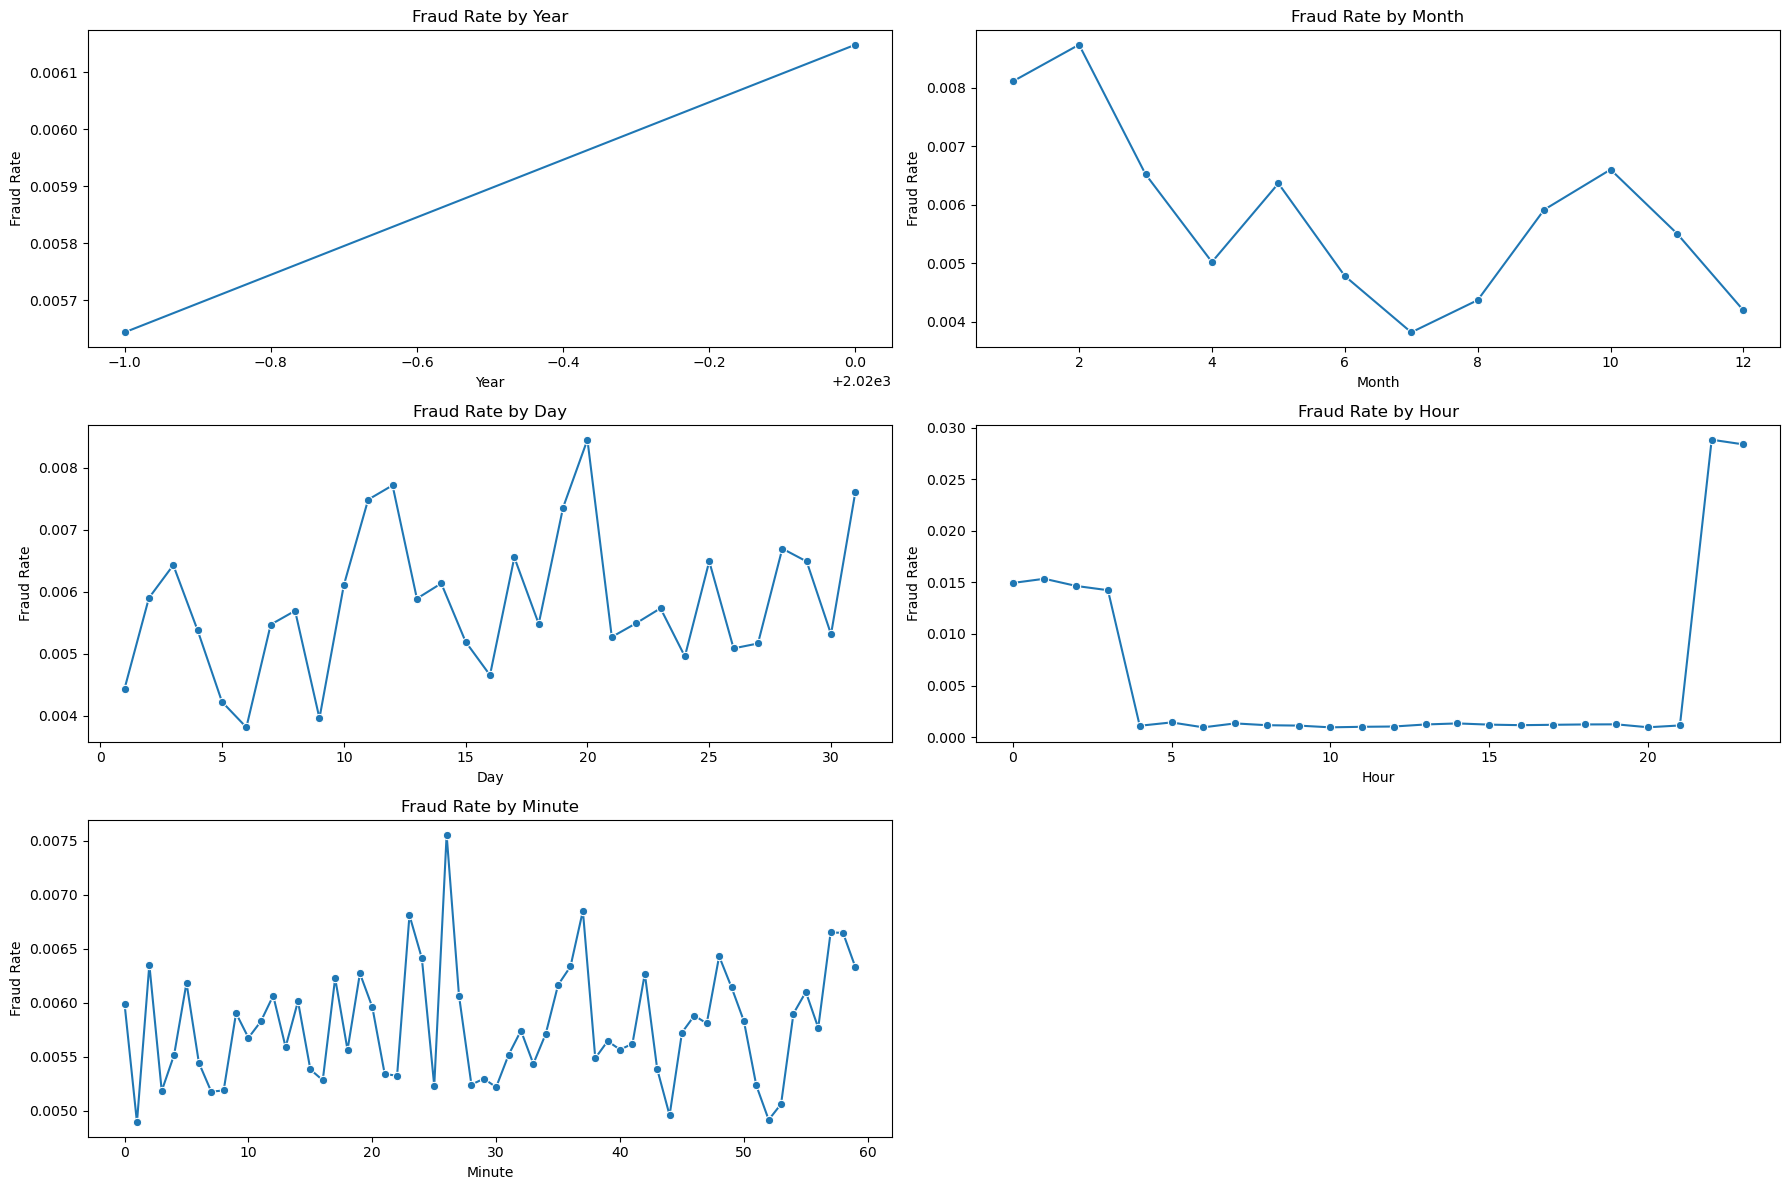

time: 682 ms (started: 2026-03-15 19:06:15 +08:00)


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate fraud rates at different time levels
time_levels = ['year', 'month', 'day', 'hour', 'minute']

plt.figure(figsize=(18, 12))

for i, level in enumerate(time_levels, 1):
    plt.subplot(3, 2, i)
    fraud_rate = df.groupby(level)['is_fraud'].mean()
    sns.lineplot(x=fraud_rate.index, y=fraud_rate.values, marker='o')
    plt.title(f'Fraud Rate by {level.capitalize()}')
    plt.ylabel('Fraud Rate')
    plt.xlabel(level.capitalize())

plt.tight_layout()
plt.show()


### Fraud rate per age group

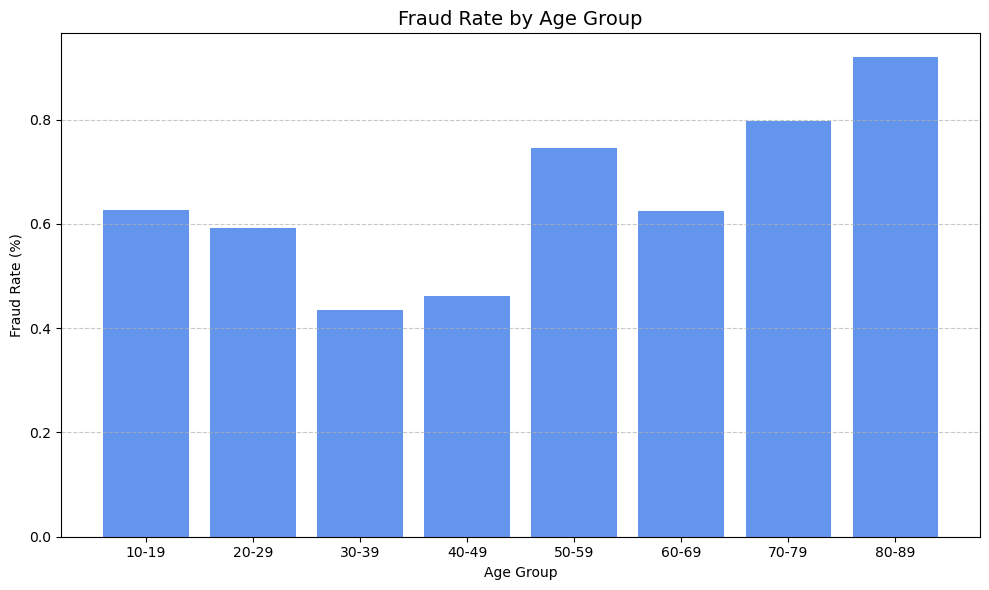

time: 160 ms (started: 2026-03-15 19:06:15 +08:00)


In [26]:
# Since age is continuous, we can create age groups to analyze fraud rates by age category.
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ['10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

# 2. Create a new age group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# 3. Group by age group and calculate fraud rate
age_grouped = (
    df.groupby('age_group')['is_fraud']
    .mean()
    .multiply(100)
    .reset_index(name='fraud_rate_%')
)

# 4. Plot histogram-style bar plot
plt.figure(figsize=(10, 6))
plt.bar(age_grouped['age_group'], age_grouped['fraud_rate_%'], color='cornflowerblue')
plt.title('Fraud Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
# Group by age group and calculate counts
age_counts = df.groupby('age_group')['is_fraud'].agg(
    non_fraud=lambda x: (x==0).sum(),
    fraud=lambda x: (x==1).sum(),
    total_txn='count'
).reset_index()

# Calculate fraud rate %
age_counts['fraud_rate_%'] = (age_counts['fraud'] / age_counts['total_txn'] * 100).round(2)

age_counts


,age_group,non_fraud,fraud,total_txn,fraud_rate_%
0,10-19,25374,160,25534,0.63
1,20-29,201743,1202,202945,0.59
2,30-39,295368,1290,296658,0.43
3,40-49,300155,1393,301548,0.46
4,50-59,189888,1425,191313,0.74
5,60-69,136029,856,136885,0.63
6,70-79,74070,595,74665,0.80
7,80-89,44059,409,44468,0.92


time: 115 ms (started: 2026-03-15 19:06:16 +08:00)


# Correlation

Age appears to be a meaningful factor in fraud risk, with older age groups exhibiting higher relative fraud rates.

In [28]:
corr_matrix = df.corr(numeric_only=True)
fraud_corr = corr_matrix['is_fraud'].drop('is_fraud')  # drop self-correlation
fraud_corr


amt           0.219404
zip          -0.002162
lat           0.001894
long          0.001721
city_pop      0.002136
merch_lat     0.001741
merch_long    0.001721
day           0.003848
month        -0.012409
year          0.003004
hour          0.013799
minute        0.001033
year_dob     -0.012378
age           0.012453
Name: is_fraud, dtype: float64

time: 701 ms (started: 2026-03-15 19:06:16 +08:00)


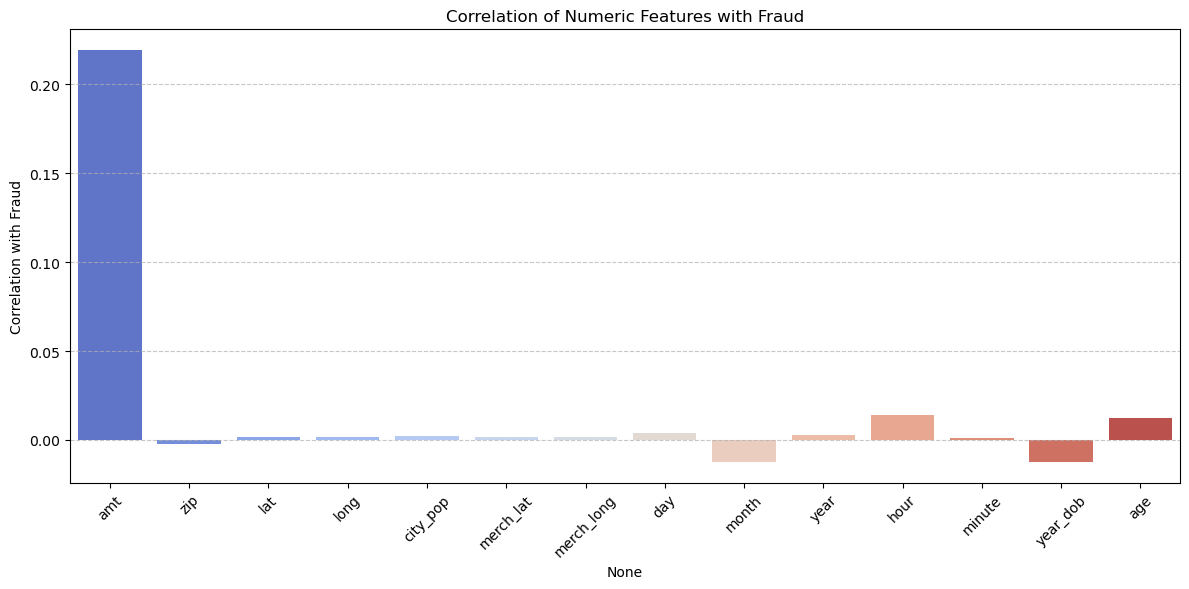

time: 358 ms (started: 2026-03-15 19:06:16 +08:00)


In [29]:
# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=fraud_corr.index, y=fraud_corr.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel('Correlation with Fraud')
plt.title('Correlation of Numeric Features with Fraud')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Correlation Insights:

1. Transaction amount (amt) has the highest positive correlation with fraud at 0.22, meaning higher amounts are somewhat more likely to be fraudulent, though the relationship is still moderate.
2. Age (age) and hour of transaction (hour) show small positive correlations (~0.012–0.013), suggesting slight tendencies for fraud to occur among certain ages and at specific hours.
3. Most other features—zip, latitude, longitude, city population, merchant location, day, month, year, minute, year of birth—have correlations very close to zero, indicating little to no linear relationship with fraud.
4. Negative correlations are minimal, e.g., month (-0.012) and year_dob (-0.012), suggesting slightly lower fraud likelihood in certain months or older birth years, but these effects are very weak.

# Model Development

In [60]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.decomposition import PCA


# for use with CAP report
from scipy import integrate

# feature power transformation functions
from scipy.stats import boxcox
from scipy.special import boxcox1p

# normality tests
from scipy.stats import shapiro
from scipy.stats import normaltest
from scipy.stats import probplot

# pip install imbalanced-learn (open anaconda prompt as admin)
# sudo pip install imbalanced-learn (macos/linux)
# pip install delayed (only do this if required)
# This module is used for handling imbalanced data
from imblearn.over_sampling import SMOTE


import numpy as np
import pandas as pd

time: 915 μs (started: 2026-03-15 19:28:54 +08:00)


## Unsupervised Learning

In [31]:
# --- 1. Safe feature selection based on EDA ---
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
drop_numeric = ['is_fraud', 'zip', 'year_dob', 'dob']
numeric_features = [col for col in numeric_features if col not in drop_numeric]

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
drop_categorical = ['gender', 'state']
categorical_features = [col for col in categorical_features if col not in drop_categorical]

X = df[numeric_features + categorical_features].copy()
y_true = df['is_fraud'].values


time: 87.8 ms (started: 2026-03-15 19:06:17 +08:00)


In [32]:
# --- 2. Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['amt', 'lat', 'long', 'city_pop', 'merch_lat',
                                  'merch_long']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['merchant', 'category', 'job', 'age_group'])])

time: 7.24 ms (started: 2026-03-15 19:06:17 +08:00)


In [33]:
# --- 3 for dimensionality reduction ---
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
svd

TruncatedSVD(n_components=100, random_state=42)

time: 5.94 ms (started: 2026-03-15 19:06:17 +08:00)


In [34]:
# --- 4. Unsupervised models ---
models = {
    "Isolation Forest": IsolationForest(contamination=y_true.mean(), random_state=42),
    "Local Outlier Factor": LocalOutlierFactor(contamination=y_true.mean(), novelty=True),
    "One-Class SVM": OneClassSVM(nu=y_true.mean(), kernel='rbf')
}

models

{'Isolation Forest': IsolationForest(contamination=0.005788651743883394, random_state=42),
 'Local Outlier Factor': LocalOutlierFactor(contamination=0.005788651743883394, novelty=True),
 'One-Class SVM': OneClassSVM(nu=0.005788651743883394)}

time: 5.79 ms (started: 2026-03-15 19:06:17 +08:00)


In [ ]:
# --- 5. Run pipeline for each model ---
summary = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('svd', svd),
        ('model', model)
    ])
    
    # Fit
    pipeline.fit(X)
    
    # Transform
    transformed_X = pipeline.named_steps['svd'].transform(
        pipeline.named_steps['preprocessor'].transform(X)
    )
    
    # Predict
    y_pred_raw = pipeline.named_steps['model'].predict(transformed_X)
    
    # Convert to 0=normal, 1=fraud
    y_pred = np.where(y_pred_raw == 1, 0, 1)
    
    # Metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    detected_fraud = y_pred.sum()
    
    summary.append({
        "Algorithm": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "Predicted Fraud": detected_fraud
    })

# --- 6. Results ---
results1 = pd.DataFrame(summary)
results1


| Algorithm            | Precision  | Recall     | F1         | Predicted Fraud |
| -------------------- | ---------- | ---------- | ---------- | --------------- |
| Isolation Forest     | 0.0152     | 0.0152     | 0.0152     | 7,503           |
| Local Outlier Factor | **0.1083** | **0.0901** | **0.0983** | 6,244           |
| One-Class SVM        | 0.0886     | 0.0886     | 0.0886     | 7,503           |


The performance of the unsupervised anomaly detection models shows that detecting fraudulent transactions without labeled information is challenging. Overall, the models produced relatively low precision and recall values, indicating difficulty in distinguishing fraudulent from legitimate transactions.

Among the evaluated algorithms, Local Outlier Factor (LOF) achieved the best overall performance with a precision of 0.1083 and recall of 0.0901, resulting in an F1-score of 0.0983. This suggests that LOF was more effective at identifying local density anomalies within the transaction dataset compared to the other methods.

In contrast, Isolation Forest exhibited the weakest performance, with precision and recall both equal to 0.0152, indicating that only a small proportion of the predicted anomalies corresponded to actual fraudulent transactions. Although Isolation Forest predicted 7,503 anomalous transactions, very few of these corresponded to true fraud cases.

Similarly, One-Class SVM demonstrated modest performance with precision and recall of 0.0886, identifying 7,503 anomalous transactions. While this method performed better than Isolation Forest, its predictive capability remained limited.

The relatively low performance across models can be attributed to the extreme class imbalance in the dataset, where fraudulent transactions represent a very small fraction of total observations. Without access to labeled training signals, unsupervised models rely solely on deviations from normal transaction patterns, which may not always correspond directly to fraudulent behavior.

### KMeans

   n_clusters  Accuracy  Precision  Sensitivity  Specificity  F1-Score  \
0           2    0.3829     0.0059       0.6287       0.3814    0.0117   
1           3    0.1789     0.0058       0.8261       0.1752    0.0115   
2           4    0.5109     0.0061       0.5164       0.5109    0.0121   
3           5    0.5330     0.0062       0.4972       0.5332    0.0122   

   Predicted Fraud  
0           802151  
1          1069554  
2           634425  
3           605547  


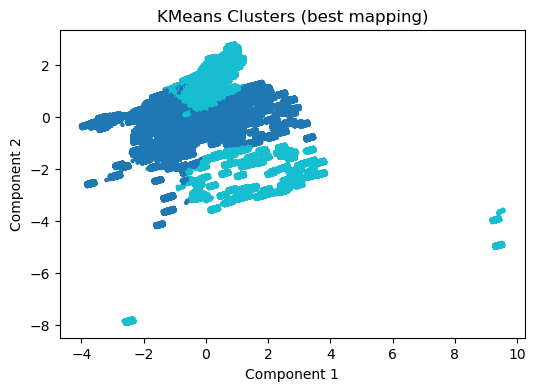

time: 46.2 s (started: 2026-03-15 19:06:17 +08:00)


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


# --- 1. Preprocess features ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# --- 2. Dimensionality reduction ---
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_processed)

# --- 3. Test different n_clusters ---
cluster_options = [2, 3, 4, 5]
summary = []

for n in cluster_options:
    kmeans = KMeans(n_clusters=n, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    
    # Map cluster labels to fraud = 1 or 0 (choose best)
    mapping_options = [labels % 2, 1 - (labels % 2)]
    best_y_pred = None
    best_f1 = -1
    for option in mapping_options:
        f1 = f1_score(y_true, option, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_y_pred = option
            
    y_pred = best_y_pred
    
    # --- 4. Metrics ---
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    
    summary.append({
        "n_clusters": n,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Sensitivity": round(sensitivity,4),
        "Specificity": round(specificity,4),
        "F1-Score": round(f1,4),
        "Predicted Fraud": y_pred.sum()
    })
    
# --- 5. Results ---
results_df = pd.DataFrame(summary)
print(results_df)

# --- 6. Optional 2D visualization ---
plt.figure(figsize=(6,4))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y_pred, cmap='tab10', s=5)
plt.title("KMeans Clusters (best mapping)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


The results indicate that the KNN-based fraud detection model demonstrates poor classification performance across all clustering configurations. Although the model achieves its highest accuracy when five clusters are used (53.3%), this improvement is marginal and still reflects weak predictive capability. Precision values remain extremely low across all models (approximately 0.6%), indicating that only a very small proportion of transactions predicted as fraudulent are actually fraud cases.

While the model exhibits relatively higher sensitivity when three clusters are used (82.6%), this is accompanied by a substantial increase in the number of predicted fraud cases, suggesting that the model tends to over-classify transactions as fraudulent, resulting in a large number of false positives. Consequently, the F1-scores across all configurations remain very low (around 0.01), indicating poor balance between precision and recall.

Overall, these findings suggest that the current modeling approach is not effective for fraud detection, likely due to severe class imbalance in the dataset or limitations in the clustering-based preprocessing approach.

### Birch --- takes too long

In [ ]:
# from sklearn.cluster import Birch

# # --- 1. Preprocessed and reduced features (reuse from before) ---
# X_processed = preprocessor.fit_transform(X)
# X_reduced = svd.fit_transform(X_processed)

# # --- 2. Fit Birch ---
# birch = Birch(n_clusters=2)  # You can try n_clusters=None to let it decide
# labels = birch.fit_predict(X_reduced)

# # --- 3. Map cluster labels to fraud = 1 or 0 (choose best) ---
# mapping_options = [labels % 2, 1 - (labels % 2)]
# best_y_pred = None
# best_f1 = -1
# for option in mapping_options:
#     f1 = f1_score(y_true, option, zero_division=0)
#     if f1 > best_f1:
#         best_f1 = f1
#         best_y_pred = option

# y_pred = best_y_pred

# # --- 4. Metrics ---
# tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
# accuracy = accuracy_score(y_true, y_pred)
# precision = precision_score(y_true, y_pred, zero_division=0)
# sensitivity = recall_score(y_true, y_pred)
# specificity = tn / (tn + fp)
# f1 = f1_score(y_true, y_pred)
# detected_fraud = y_pred.sum()

# # --- 5. Results ---
# results_birch = pd.DataFrame([{
#     "Algorithm": "Birch",
#     "Clusters": len(np.unique(labels)),
#     "Accuracy": round(accuracy,4),
#     "Precision": round(precision,4),
#     "Sensitivity": round(sensitivity,4),
#     "Specificity": round(specificity,4),
#     "F1-Score": round(f1,4),
#     "Predicted Fraud": detected_fraud
# }])

# print(results_birch)

# # --- 6. Optional 2D visualization ---
# plt.figure(figsize=(6,4))
# plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y_pred, cmap='tab10', s=5)
# plt.title(f"Birch Clusters (total clusters={len(np.unique(labels))})")
# plt.xlabel("Component 1")
# plt.ylabel("Component 2")
# plt.show()


### Unsupervised Outlier Detection using Local Outlier Factor (LOF)

In [36]:
numeric_features

['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']

time: 1.23 ms (started: 2026-03-15 19:07:12 +08:00)


In [40]:
df

,merchant,category,amt,gender,state,zip,lat,long,city_pop,job,...,merch_long,is_fraud,day,month,year,hour,minute,year_dob,age,age_group
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",...,-82.048315,0,1,1,2019,0,0,1988,31,30-39
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,...,-118.186462,0,1,1,2019,0,0,1978,41,40-49
2,fraud_Lind-Buckridge,entertainment,220.11,M,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,...,-112.154481,0,1,1,2019,0,0,1962,57,50-59
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,MT,59632,46.2306,-112.1138,1939,Patent attorney,...,-112.561071,0,1,1,2019,0,1,1967,52,50-59
4,fraud_Keeling-Crist,misc_pos,41.96,M,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,...,-78.632459,0,1,1,2019,0,3,1986,33,30-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,UT,84735,37.7175,-112.4777,258,Geoscientist,...,-111.690765,0,21,6,2020,12,12,1961,59,50-59
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,MD,21790,39.2667,-77.5101,100,"Production assistant, television",...,-78.246528,0,21,6,2020,12,12,1979,41,40-49
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,NM,88325,32.9396,-105.8189,899,Naval architect,...,-105.130529,0,21,6,2020,12,12,1967,53,50-59
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,...,-103.241160,0,21,6,2020,12,13,1980,40,40-49


time: 351 ms (started: 2026-03-15 19:20:37 +08:00)


In [ ]:
# y = df.is_fraud
# X = df.drop(['is_fraud'],axis=1)

In [42]:
# Since LOF can be memory intensive, we will sample a subset of the data for demonstration.
df_sample = df.sample(500000, random_state=42)

X_processed = df_sample[numeric_features].fillna(df_sample[numeric_features].median())

lof = LocalOutlierFactor(n_neighbors=20)
y_pred = lof.fit_predict(X_processed)

time: 7.72 s (started: 2026-03-15 19:21:16 +08:00)


In [46]:
tmp_df = pd.DataFrame(y_pred)
tmp_df.value_counts()

0 
 1    492811
-1      7189
Name: count, dtype: int64

time: 35.2 ms (started: 2026-03-15 19:22:42 +08:00)


The Local Outlier Factor (LOF) algorithm was applied to detect anomalous transactions in the dataset. The model identified 492,811 observations (98.56%) as normal transactions, while 7,189 observations (1.44%) were classified as outliers. These outliers represent transactions whose characteristics significantly deviate from the local neighborhood structure of the data and may therefore indicate potential fraudulent activity. The relatively small proportion of detected anomalies is consistent with the expected rarity of fraud events in real-world financial transaction datasets.

### Grubb's Test

'Before'

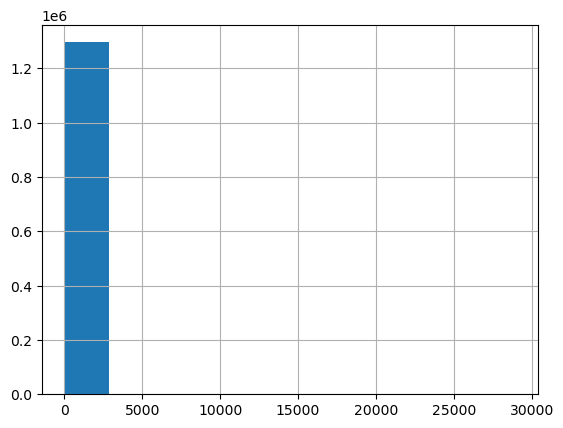

'After'

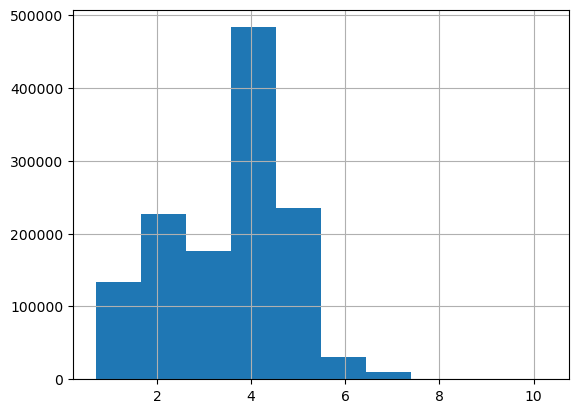

time: 518 ms (started: 2026-03-15 19:23:48 +08:00)


In [48]:
from scipy.special import boxcox1p

series_tmp = df['amt'].copy()

display("Before")
series_tmp.hist()
plt.show()
# you can see here that our distribution skews to the left which is different to the bellcurve of a normal/gaussian distribution

# To address this, we use a power transformation and try to make our dataset look normal/gaussian
# The Boxcox function accepts a lambda parameter that dictates what transformation to do
# In this case a lambda value of 0 means it will do a log transformation to all of the data set
boxcox_series_tmp = pd.Series(boxcox1p(series_tmp,0))
display("After")
boxcox_series_tmp.hist()
plt.show()


'Before'

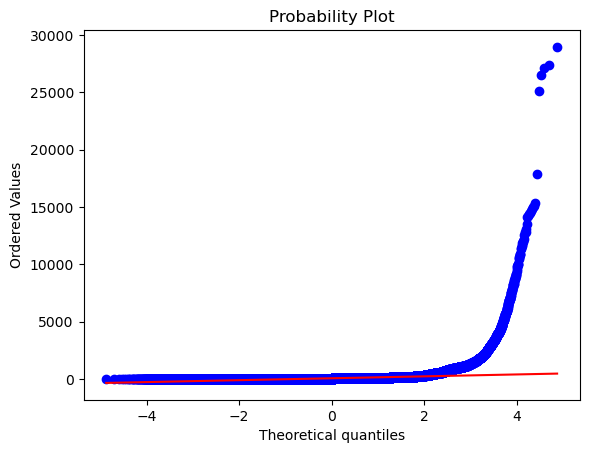

'After'

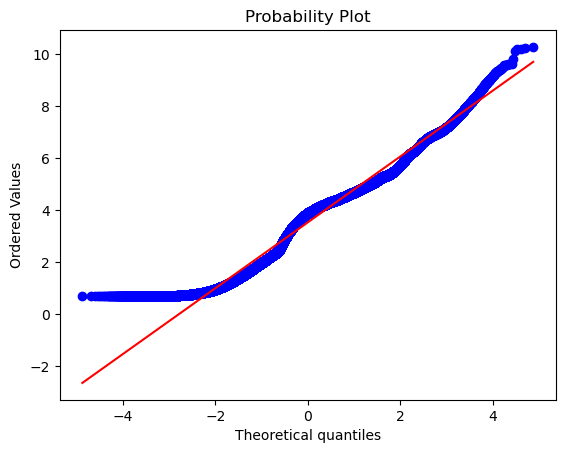

time: 2.83 s (started: 2026-03-15 19:24:25 +08:00)


In [49]:
from scipy.stats import probplot

display("Before")
probplot(series_tmp, dist="norm", plot=plt)
plt.show()


display("After")

probplot(boxcox_series_tmp, dist="norm", plot=plt)
plt.show()



In [51]:
print("Using Shapiro Normality Test")
print("Before: ")
print(shapiro(series_tmp))

print("After")
print(shapiro(boxcox_series_tmp))

# The Shapiro-Wilk test evaluates a data sample and quantifies how likely it is that the data was drawn from a
# Gaussian distribution, named for Samuel Shapiro and Martin Wilk.

print("")

print("Using D’Agostino’s K^2 Normality Test")
print("Before: ")
print(normaltest(series_tmp))

print("After")
print(normaltest(boxcox_series_tmp))

Using Shapiro Normality Test
Before: 
ShapiroResult(statistic=0.269781677815625, pvalue=1.110057323349835e-229)
After
ShapiroResult(statistic=0.9611609114355852, pvalue=1.253251610331245e-127)

Using D’Agostino’s K^2 Normality Test
Before: 
NormaltestResult(statistic=3855720.1938770907, pvalue=0.0)
After
NormaltestResult(statistic=47331.10727850435, pvalue=0.0)
time: 448 ms (started: 2026-03-15 19:25:23 +08:00)


Since p-value is very small, we reject the null hypothesis. Meaning, the data is not normally distributed

In [72]:
import numpy as np
from scipy import stats

def grubbs_test(data, alpha=0.05):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)

    G = np.max(np.abs(data - mean)) / std
    n = len(data)

    t = stats.t.ppf(1 - alpha/(2*n), n-2)
    G_crit = ((n-1)/np.sqrt(n)) * np.sqrt(t**2 / (n-2 + t**2))

    if G > G_crit:
        return data[np.argmax(np.abs(data - mean))]
    return None

print("Our transformed data set length count:")
print(len(boxcox_series_tmp))

outlier = grubbs_test(boxcox_series_tmp, alpha=0.05)

if outlier is not None:
    grubbs_result = boxcox_series_tmp[boxcox_series_tmp != outlier]
else:
    grubbs_result = boxcox_series_tmp

print("Our Grubbs test result length count:")
print(len(grubbs_result))

print("Grubbs test works by returning the dataset and removing the anomalies.")

Our transformed data set length count:
1296675
Our Grubbs test result length count:
1296675
Grubbs test works by returning the dataset and removing the anomalies.
time: 13.9 ms (started: 2026-03-15 19:33:41 +08:00)


The Grubbs test was applied to the Box–Cox transformed dataset to detect extreme outliers. The results indicated that no statistically significant outliers were identified at the 0.05 significance level, as the number of observations remained unchanged (N = 1,296,675). This suggests that the transformed data does not contain extreme deviations from the sample mean according to the Grubbs test criterion.

In [61]:
import numpy as np
from scipy import stats

def grubbs_test(data, alpha=0.05):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    
    # compute G statistic
    G = np.max(np.abs(data - mean)) / std
    n = len(data)
    
    # critical value
    t = stats.t.ppf(1 - alpha/(2*n), n-2)
    G_crit = ((n-1)/np.sqrt(n)) * np.sqrt(t**2 / (n-2 + t**2))
    
    if G > G_crit:
        outlier = data[np.argmax(np.abs(data - mean))]
        return outlier
    else:
        return None

time: 785 μs (started: 2026-03-15 19:29:07 +08:00)


In [64]:
import numpy as np

print("Our transformed data set length count:")
print(len(boxcox_series_tmp))

data = np.array(boxcox_series_tmp)

outlier = grubbs_test(data, alpha=0.05)

if outlier is not None:
    grubbs_result = data[data != outlier]
else:
    grubbs_result = data

print("Our Grubbs test result length count:")
print(len(grubbs_result))

print("Grubbs test works by returning the dataset and removing the anomalies.")
print("You can see the difference in length if an anomaly was detected.")

Our transformed data set length count:
1296675
Our Grubbs test result length count:
1296675
Grubbs test works by returning the dataset and removing the anomalies.
You can see the difference in length if an anomaly was detected.
time: 15.2 ms (started: 2026-03-15 19:30:01 +08:00)


##  Supervised Learning

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import Parallel, delayed
import numpy as np

# --- 1. Split data ---
X = df[numeric_features + categorical_features].copy()
y = df['is_fraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- 2. Preprocessing ---
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# --- 3. Preprocess once ---
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# --- 4. Convert to dense for CatBoost only ---
X_train_dense = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
X_test_dense = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

# --- 5. Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1,
        scale_pos_weight=int((len(y)-sum(y))/sum(y)),
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(
        n_estimators=200, learning_rate=0.1,
        auto_class_weights='Balanced', verbose=0,
        random_state=42, thread_count=1  # <-- single thread to avoid sparse/parallel issues
    )
}

# --- 6. Resampling strategies ---
resampling_strategies = {
    "No Resampling": None,
    "Oversampling": SMOTE(random_state=42),
    "Undersampling": RandomUnderSampler(random_state=42)
}

# --- 7. Train & evaluate function ---
def train_evaluate(model_name, model, strategy_name, resampler):
    # For CatBoost use dense arrays
    if model_name == "CatBoost":
        X_tr, X_te = X_train_dense, X_test_dense
    else:
        X_tr, X_te = X_train_proc, X_test_proc
    
    if resampler:
        pipeline = ImbPipeline(steps=[
            ('resampler', resampler),
            ('classifier', model)
        ])
        pipeline.fit(X_tr, y_train)
        y_pred = pipeline.predict(X_te)
        y_proba = pipeline.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None
    else:
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None
    
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    return {
        "Resampling": strategy_name,
        "Algorithm": model_name,
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score'],
        "ROC-AUC": auc,
        "Predicted Fraud": y_pred.sum()
    }

# --- 8. Run all models in parallel ---
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_evaluate)(name, model, strat_name, resampler)
    for strat_name, resampler in resampling_strategies.items()
    for name, model in models.items()
)

# --- 9. Compile results ---
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
results_df

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:15:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 6005, number of negative: 1031335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3916
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 1201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.7min
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public 

[LightGBM] [Info] Number of positive: 1031335, number of negative: 1031335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.237594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128486
[LightGBM] [Info] Number of data points in the train set: 2062670, number of used features: 1216
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_fe

[LightGBM] [Info] Number of positive: 6005, number of negative: 6005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2543
[LightGBM] [Info] Number of data points in the train set: 12010, number of used features: 513
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `skle

,Resampling,Algorithm,Precision,Recall,F1-Score,ROC-AUC,Predicted Fraud
8,Oversampling,Random Forest,0.829016,0.639574,0.722076,0.973991,1158
1,No Resampling,Random Forest,0.899142,0.558294,0.688861,0.969041,932
10,Oversampling,Decision Tree,0.598961,0.691539,0.641929,0.844422,1733
3,No Resampling,Decision Tree,0.593714,0.679547,0.633737,0.838420,1718
12,Oversampling,LightGBM,0.418627,0.865423,0.564292,0.994740,3103
13,Oversampling,CatBoost,0.288740,0.890073,0.436031,0.993761,4627
5,No Resampling,LightGBM,0.188209,0.950700,0.314213,0.995930,7582
9,Oversampling,Gradient Boosting,0.190231,0.884744,0.313134,0.988912,6981
15,Undersampling,Random Forest,0.174747,0.910060,0.293196,0.990956,7817
4,No Resampling,XGBoost,0.153273,0.959360,0.264317,0.995311,9395


time: 1h 5min 52s (started: 2026-03-15 20:15:15 +08:00)


A comparison of classification models for fraud detection is presented in Table 1. Among the models tested, Random Forest with oversampling (SMOTE) demonstrated the best overall performance. This model achieved a precision of 0.83, recall of 0.64, F1-score of 0.72, and a ROC-AUC of 0.97, correctly identifying 1,158 fraudulent transactions. Compared to Random Forest without resampling (F1 = 0.69, ROC-AUC = 0.97) and other algorithms, this model provided the optimal balance between sensitivity and specificity, making it the preferred choice for fraud detection in this dataset.

Other models, such as LightGBM and CatBoost with oversampling, achieved high recall values (0.87–0.89) but substantially lower precision (0.29–0.42), resulting in lower F1-scores (0.44–0.56) and indicating a high rate of false positives. Models without resampling generally exhibited higher precision but lower recall, highlighting the challenge of class imbalance in fraud detection.

Since Random Forest with oversampling (SMOTE) demonstrated the best overall performance, we then know hypertune the model and select the best parameters

### Hypertuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, f1_score

# Pipeline
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Smaller hyperparameter grid
param_distributions = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

# Faster RandomizedSearch
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,          # fewer iterations
    scoring='f1',       # optimize F1
    n_jobs=-1,
    cv=5,               # fewer folds
    verbose=2,
    random_state=42
)

# Fit
random_search.fit(X_train_proc, y_train)

# Evaluate
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test_proc)
y_proba = best_rf.predict_proba(X_test_proc)[:,1]

print("Best F1 Score:", random_search.best_score_)
print("Best Params:", random_search.best_params_)
print(classification_report(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning:

[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=10, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 3.2min


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=10, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=100; total time= 3.2min


...

[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=None, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=5, classifier__n_estimators=150; total time=82.0min


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=200; total time=48.8min


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=200; total time=49.4min
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=200; total time=49.2min
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=200; total time=49.4min


A hyperparameter-tuned Random Forest classifier with oversampling using SMOTE was evaluated for fraud detection. Hyperparameter optimization was performed using RandomizedSearchCV with 20 random combinations and 5-fold cross-validation, optimizing for the F1-score to balance precision and recall. The tuning process included a progress bar for real-time monitoring, providing visibility into the model search process and reducing uncertainty during long computations.

The optimized pipeline incorporated SMOTE to address class imbalance in the training data, while the Random Forest classifier was tuned over parameters including n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, and class_weight.